# Hopf--Cole Transforms and Soft Hopf--Lax Operators

The Sinkhorn soft minimum is one face of a broader heat-kernel calculus.  The Hopf--Cole transform turns the viscous Hamilton--Jacobi equation into a heat equation, and the same formula gives a Gaussian-blurred approximation of the Hopf--Lax transform.  After completing the square, the hard transform can be written as a quadratic Legendre--Fenchel transform,
$$
    Q_t f(x)=\frac{|x|^2}{2t}-\left(f+\frac{|\cdot|^2}{2t}\right)^*\!\left(\frac{x}{t}\right).
$$
Its entropic version is
$$
    Q_t^\varepsilon f(x)
    = -\varepsilon \log \int \exp\!\left(-\frac{f(y)+|x-y|^2/(2t)}{\varepsilon}\right)dy.
$$
As $\varepsilon\to0$, Laplace's principle recovers the hard infimum $Q_t f(x)=\inf_y f(y)+|x-y|^2/(2t)$.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import RED, BLUE, VIOLET, LIGHT_GRAY, GRAY, interp_color, figure_dir, save_pdf, setup_matplotlib, box_axes

setup_matplotlib()

NAME = "sinkhorn-hopf-cole-transform"
OUT = figure_dir(NAME)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)


## Gaussian soft Hopf--Lax transform

The numerical formula is a direct log-sum-exp implementation of a Gaussian convolution.  With the heat-kernel convention $G_s(x-y)\propto \exp(-|x-y|^2/(4s))$, the convolution time is $s=\varepsilon t/2$.  Additive constants are irrelevant for Hamilton--Jacobi potentials, so the soft curves are vertically aligned with the hard Hopf--Lax/Legendre transform by their minima.

In [2]:
x = np.linspace(-3.0, 3.0, 900)
y = x.copy()
dy = y[1] - y[0]
t_hl = 0.56
f0 = 0.18 * (y**2 - 1.25) ** 2 + 0.13 * y + 0.08 * np.sin(2.4 * y)
values = f0[None, :] + (x[:, None] - y[None, :]) ** 2 / (2 * t_hl)
hard = values.min(axis=1)

def soft_hopf_lax(eps):
    m = values.min(axis=1)
    weights = np.exp(-(values - m[:, None]) / eps)
    val = m - eps * np.log(np.sum(weights, axis=1) * dy)
    val += hard.min() - val.min()
    return val

soft_small = soft_hopf_lax(0.045)
soft_large = soft_hopf_lax(0.18)


In [3]:
soft_ymin = min(np.min(hard), np.min(f0 - 0.82)) - 0.05
soft_ymax = np.quantile(f0, 0.82)

def draw_soft_hopf_lax(path):
    fig, ax = plt.subplots(figsize=(3.05, 1.85))
    ax.plot(x, hard, color=VIOLET, lw=1.35)
    ax.plot(x, soft_small, color=interp_color(0.35), lw=1.15)
    ax.plot(x, soft_large, color=interp_color(0.70), lw=1.15)
    ax.plot(y, f0 - 0.82, color=LIGHT_GRAY, lw=0.82, alpha=0.92)
    ax.set_xlim(-2.65, 2.65)
    ax.set_ylim(soft_ymin, soft_ymax)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"value")
    ax.tick_params(labelsize=7, pad=1.5)
    box_axes(ax)
    save_pdf(fig, OUT / path, pad_inches=0.045)
    plt.close(fig)

draw_soft_hopf_lax("soft-hopf-lax.pdf")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Hopf--Cole solution of viscous Burgers

For $\nu>0$, set $u=\exp(-\phi/(2\nu))$.  If $u_t=\nu u_{xx}$, then $v=\phi_x=-2\nu\partial_x\log u$ solves viscous Burgers,
$$
    \partial_t v + v\partial_x v = \nu \partial_{xx}v.
$$
We solve the heat equation spectrally on a periodic interval and recover the Burgers velocity by differentiating $\log u$.

In [4]:
N = 1024
period = 2 * np.pi
xb = np.linspace(-np.pi, np.pi, N, endpoint=False)
dxb = xb[1] - xb[0]
nu = 0.12
phi0 = 0.16 * np.cos(xb - 0.25) + 0.065 * np.cos(2 * xb + 0.65) - 0.035 * np.sin(3 * xb)
u0 = np.exp(-phi0 / (2 * nu))
k = 2 * np.pi * np.fft.fftfreq(N, d=dxb)
u0_hat = np.fft.fft(u0)
times = np.array([0.0, 0.10, 0.32, 0.80, 1.55])

heat_curves = []
burgers_curves = []
for t in times:
    u = np.real(np.fft.ifft(u0_hat * np.exp(-nu * (k**2) * t)))
    u = np.maximum(u, 1e-14)
    logu_hat = np.fft.fft(np.log(u))
    vx = -2 * nu * np.real(np.fft.ifft(1j * k * logu_hat))
    heat_curves.append(u / np.mean(u))
    burgers_curves.append(vx)


In [5]:
def draw_time_curves(curves, path, ylabel, ylim=None):
    fig, ax = plt.subplots(figsize=(3.05, 1.85))
    for i, curve in enumerate(curves):
        ax.plot(xb, curve, color=interp_color(i / (len(curves) - 1)), lw=1.05)
    ax.set_xlim(-np.pi, np.pi)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(ylabel)
    ax.tick_params(labelsize=7, pad=1.5)
    box_axes(ax)
    save_pdf(fig, OUT / path, pad_inches=0.045)
    plt.close(fig)

draw_time_curves(heat_curves, "heat-variable.pdf", r"$u_t$", ylim=(0.64, 1.42))
maxv = max(float(np.max(np.abs(v))) for v in burgers_curves)
draw_time_curves(burgers_curves, "burgers-velocity.pdf", r"$v_t$", ylim=(-1.08 * maxv, 1.08 * maxv))

fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.05))
# Reuse the same drawing routines on temporary axes for the thumbnail.
axes[0].plot(x, hard, color=VIOLET, lw=1.25)
axes[0].plot(x, soft_small, color=interp_color(0.35), lw=1.05)
axes[0].plot(x, soft_large, color=interp_color(0.70), lw=1.05)
axes[0].plot(y, f0 - 0.82, color=LIGHT_GRAY, lw=0.76, alpha=0.92)
axes[0].set_xlim(-2.65, 2.65)
axes[0].set_ylim(soft_ymin, soft_ymax)
for i, curve in enumerate(heat_curves):
    axes[1].plot(xb, curve, color=interp_color(i / (len(heat_curves) - 1)), lw=1.0)
axes[1].set_xlim(-np.pi, np.pi)
axes[1].set_ylim(0.64, 1.42)
for i, curve in enumerate(burgers_curves):
    axes[2].plot(xb, curve, color=interp_color(i / (len(burgers_curves) - 1)), lw=1.0)
axes[2].set_xlim(-np.pi, np.pi)
axes[2].set_ylim(-1.08 * maxv, 1.08 * maxv)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
fig.subplots_adjust(left=0.025, right=0.99, bottom=0.08, top=0.97, wspace=0.16)
fig.savefig(THUMB_DIR / f"{NAME}.png", dpi=180)
plt.close(fig)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

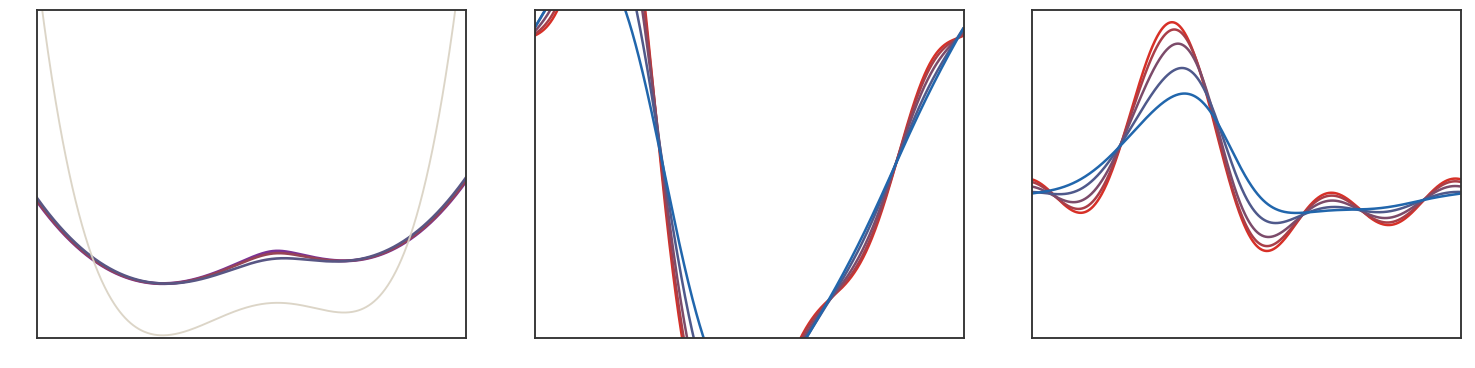

In [6]:
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-hopf-cole-transform.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-hopf-cole-transform.png")
display(Image(filename=str(_thumb)))
